## 1 dataset selection

the dataset used in this project is the seoul bike sharing demand dataset

the dataset comes from the uci machine learning repository

it contains hourly information about the seoul bike sharing system together with weather data and holiday information

the dataset was collected to study and predict the number of bikes needed at different hours

this can help improve bike availability and reduce waiting time for users

the dataset contains 8760 observations and more than 8 features so it satisfies the assignment requirements

### possible limitations

the dataset represents only one city and one year so the results may not represent other cities or time periods

bike demand is also affected by factors that are not included in the dataset such as special events traffic and changes in public transportation

some weather variables may also be related to each other which can create redundancy in the data

because the observations are recorded every hour nearby observations may not be completely independent

## 2 exploratory data analysis

in this section i will examine the structure distributions correlations and possible outliers in the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# find the data file
file_name = "SeoulBikeData.csv"

possible_paths = [Path("data") / file_name,Path("..") / "data" / file_name]
possible_paths.extend(Path.cwd().glob(f"*/data/{file_name}"))
file_path = next((path for path in possible_paths if path.exists()),None)

if file_path is None:raise FileNotFoundError("SeoulBikeData.csv was not found inside a data folder")

bike_data = pd.read_csv(file_path,encoding="cp1252")
bike_data.head()

#check dataset structure
print("rows:", bike_data.shape[0])
print("columns:", bike_data.shape[1])

print("\nmissing values:")
print(bike_data.isnull().sum())

print("\ndata types:")
print(bike_data.dtypes)

# rename columns
bike_data.columns = ["date","rented_count","hour","temperature","humidity","wind_speed","visibility","dew_point_temp","solar_radiation","rainfall","snowfall","season","holiday","functioning_day"]
bike_data["date"] = pd.to_datetime(bike_data["date"],format="%d/%m/%Y")
bike_data.head()

rows: 8760
columns: 14

missing values:
Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

data types:
Date                             str
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                          str
Holiday                          str
Functioning Day    

,date,rented_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,season,holiday,functioning_day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


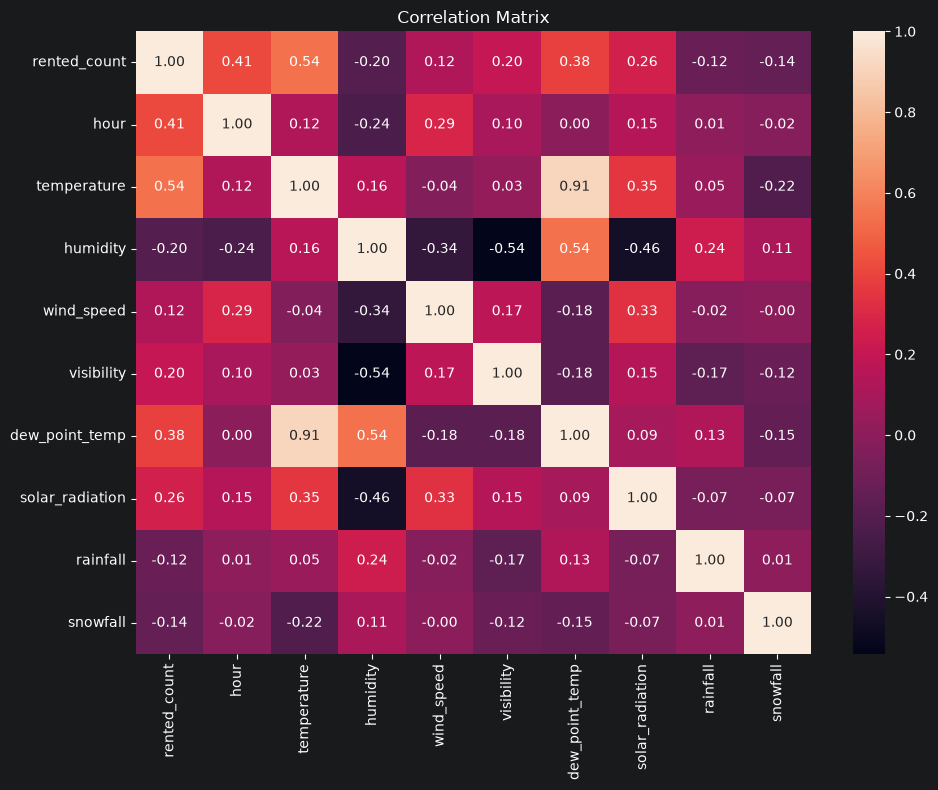

In [2]:
# statistical summary
bike_data.describe().round(2)
# choose numerical features
numerical_features = ["rented_count","hour","temperature","humidity","wind_speed","visibility","dew_point_temp","solar_radiation","rainfall","snowfall"]
# calculate correlation matrix
correlation_matrix = bike_data[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### correlation findings
temperature and dew point temperature have a very strong positive correlation

humidity also has noticeable relationships with visibility dew point temperature and solar radiation

some features therefore contain similar information

this redundancy may be important later when using pca because pca can combine correlated features into fewer components

In [3]:
# statistical summary
bike_data.describe().round(2)

,date,rented_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall
count,8760,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00
mean,2018-06-01 00:00:00,704.60,11.50,12.88,58.23,1.72,1436.83,4.07,0.57,0.15,0.08
min,2017-12-01 00:00:00,0.00,0.00,-17.80,0.00,0.00,27.00,-30.60,0.00,0.00,0.00
25%,2018-03-02 00:00:00,191.00,5.75,3.50,42.00,0.90,940.00,-4.70,0.00,0.00,0.00
50%,2018-06-01 00:00:00,504.50,11.50,13.70,57.00,1.50,1698.00,5.10,0.01,0.00,0.00
75%,2018-08-31 00:00:00,1065.25,17.25,22.50,74.00,2.30,2000.00,14.80,0.93,0.00,0.00
max,2018-11-30 00:00:00,3556.00,23.00,39.40,98.00,7.40,2000.00,27.20,3.52,35.00,8.80
std,NaN,645.00,6.92,11.94,20.36,1.04,608.30,13.06,0.87,1.13,0.44


### distribution analysis
in this section i will examine the distributions of the main numerical features

histograms boxplots skewness and kurtosis will be used to identify unusual shapes and possible outliers

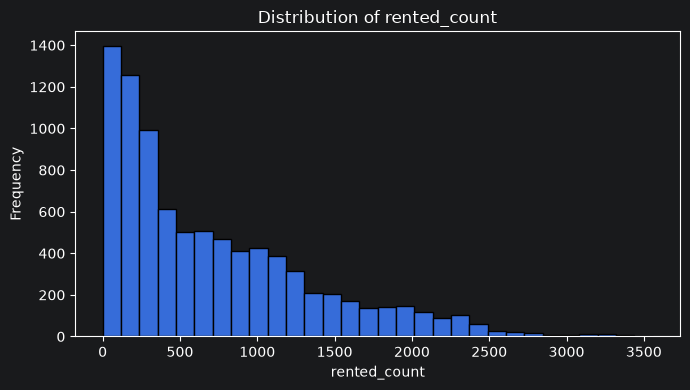

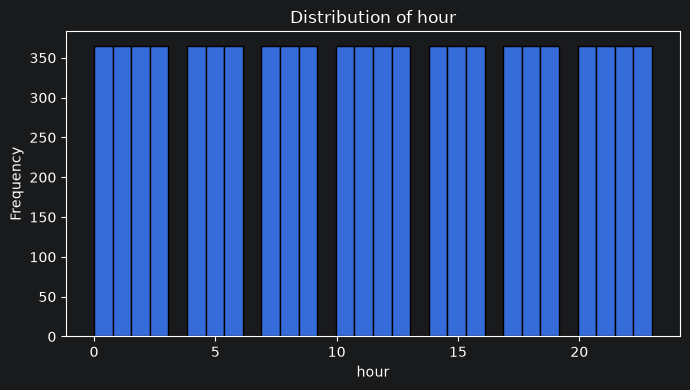

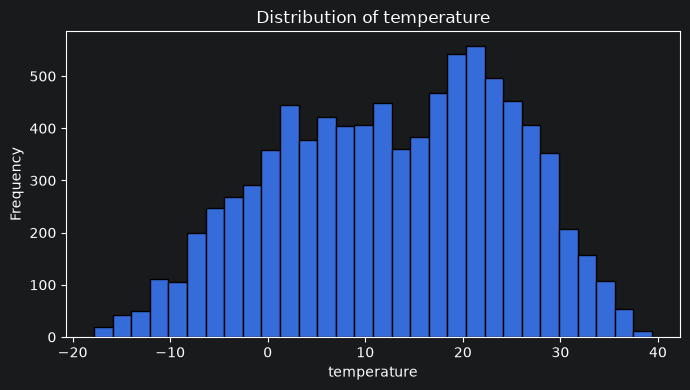

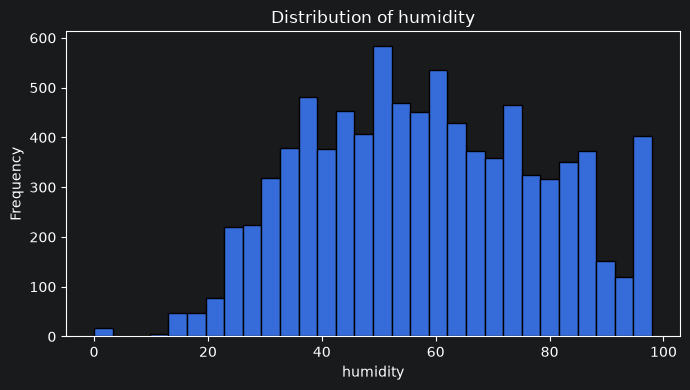

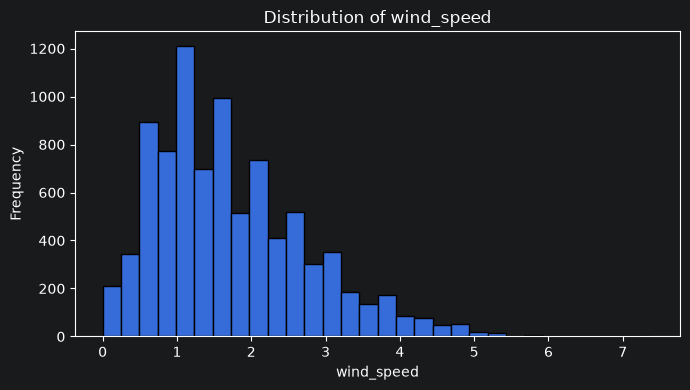

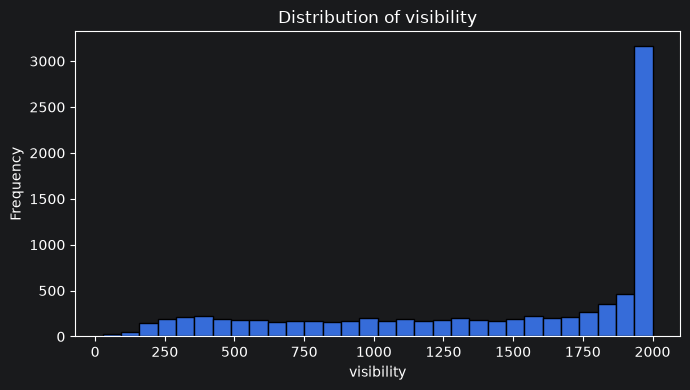

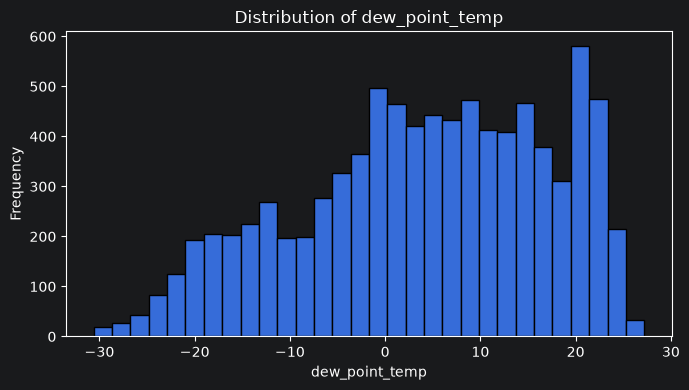

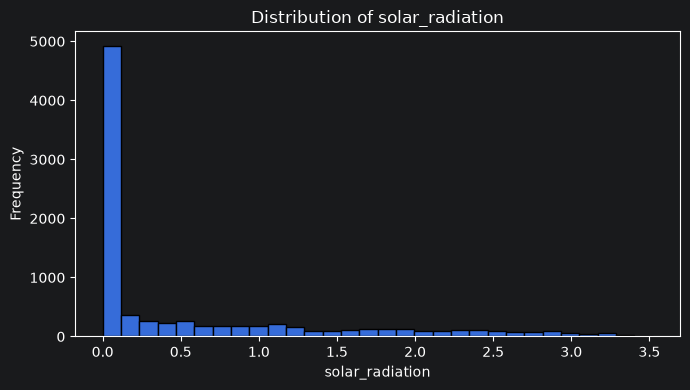

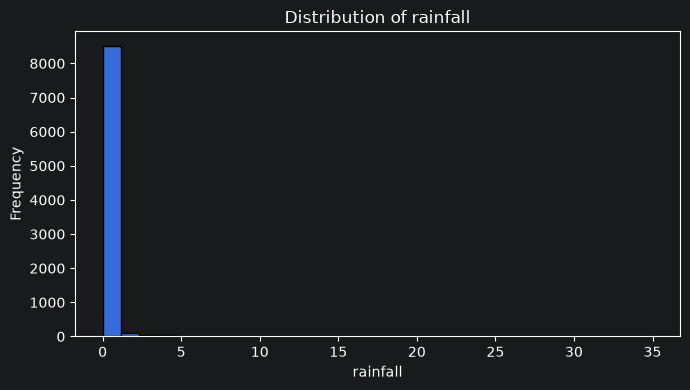

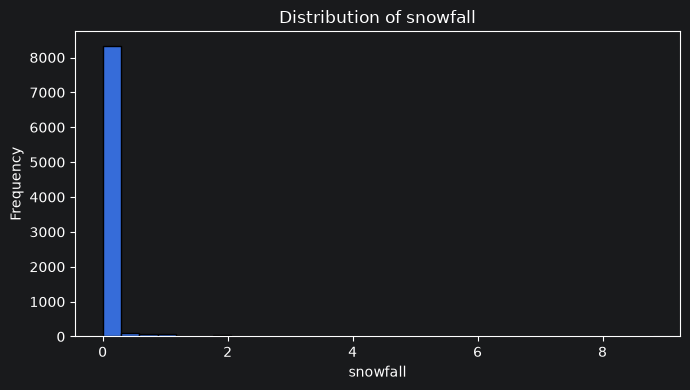

In [4]:
# plot histograms for numerical features
for column in numerical_features:

    plt.figure(figsize=(7, 4))
    plt.hist(bike_data[column],bins=30,edgecolor="black")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

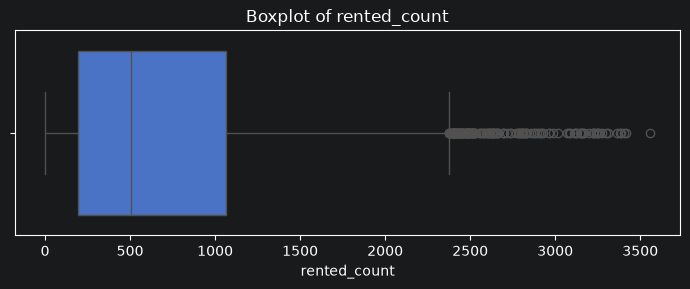

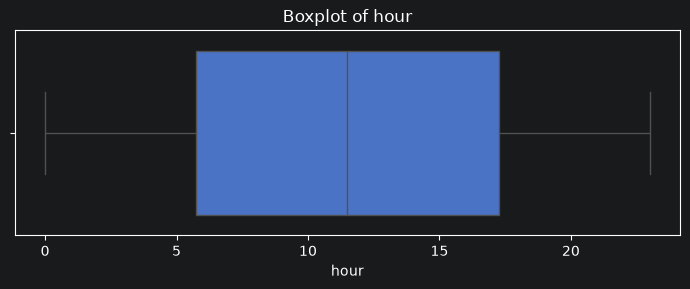

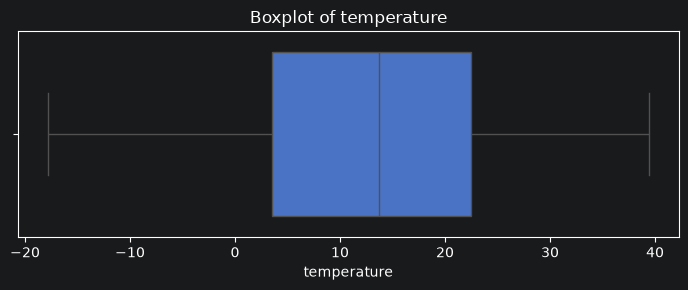

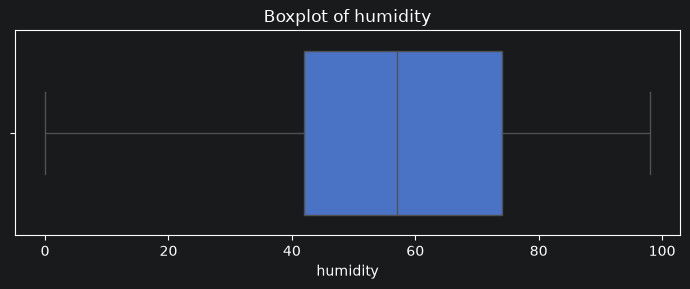

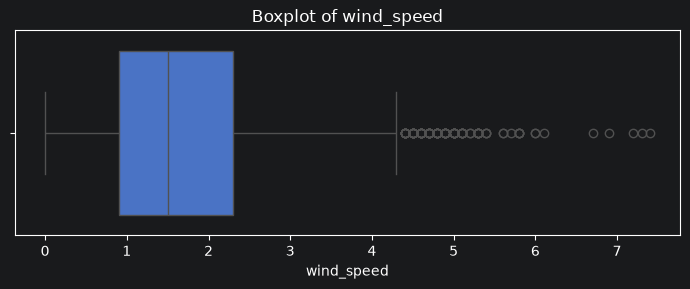

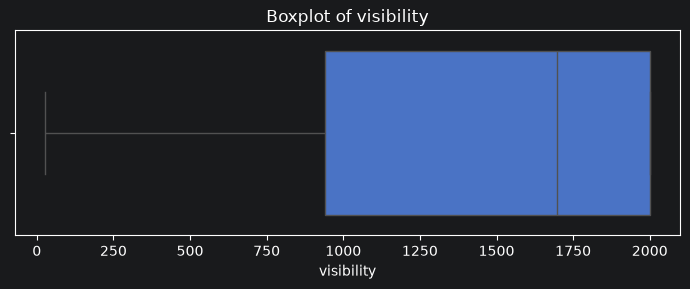

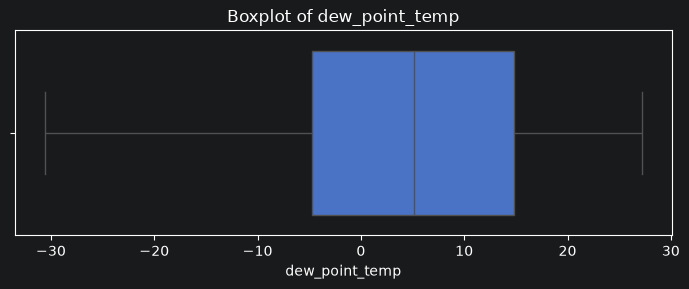

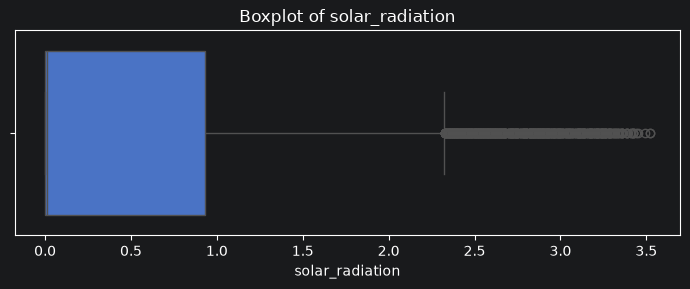

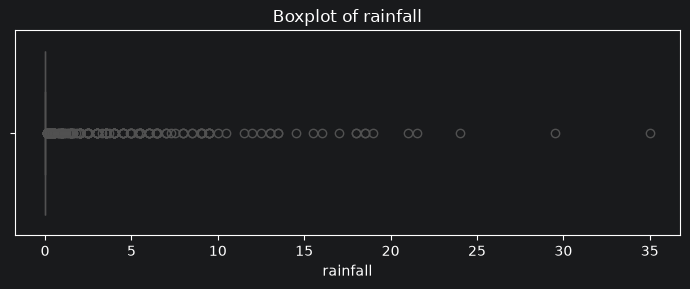

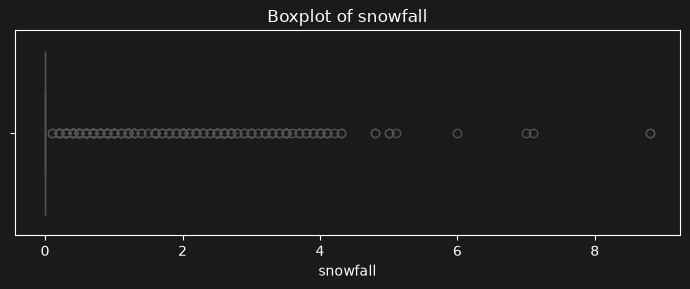

In [5]:
# plot boxplots for numerical features
for column in numerical_features:

    plt.figure(figsize=(7, 3))
    sns.boxplot(x=bike_data[column])
    plt.title(f"Boxplot of {column}")
    plt.tight_layout()
    plt.show()

In [6]:
# calculate skewness and kurtosis
distribution_summary = pd.DataFrame({"skewness": bike_data[numerical_features].skew(),"kurtosis": bike_data[numerical_features].kurt()})
distribution_summary.round(3)

,skewness,kurtosis
rented_count,1.153,0.853
hour,0.000,-1.204
temperature,-0.198,-0.838
humidity,0.060,-0.804
wind_speed,0.891,0.727
visibility,-0.702,-0.962
dew_point_temp,-0.367,-0.755
solar_radiation,1.504,1.126
rainfall,14.533,284.991
snowfall,8.441,93.803


### outlier exploration
features with high skewness or kurtosis may contain heavy tails or extreme values

boxplots can also show observations that are far from the main distribution

these values are not automatically errors because unusual weather conditions or high bike demand may still be valid observations

### distribution findings

rented bike count has a clear right skew which means that most observations have lower rental values while some hours have very high demand

wind speed and solar radiation are also right skewed

rainfall and snowfall are extremely right skewed because most observations are zero while a small number of observations have much larger values

rainfall and snowfall also have very high kurtosis which shows that their distributions have heavy tails and extreme values

hour is almost evenly distributed because every hour appears the same number of times

temperature humidity and dew point temperature are much more balanced than rainfall and snowfall

the boxplots show many extreme values in rented bike count wind speed solar radiation rainfall and snowfall

### outlier discussion

many of the extreme values are probably real observations rather than data entry errors

high rainfall snowfall wind speed or bike demand can happen naturally even if they are rare

however these extreme values may have a strong effect on distance based methods and anomaly detection

this is one reason why scaling will be important before pca clustering and anomaly detection

## 3 dimensionality reduction

### 3.1 principal component analysis

pca will be used to reduce the number of numerical features while keeping as much information as possible

the numerical features will be scaled before applying pca because they use different units and ranges

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# prepare data for pca
pca_features = bike_data[numerical_features].copy()

# scale the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_features)

# apply pca
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

# calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
variance_table = pd.DataFrame({"component": range(1,len(explained_variance) + 1),"explained_variance": explained_variance,"cumulative_variance": cumulative_variance})
variance_table.round(3)

,component,explained_variance,cumulative_variance
0,1,0.253,0.253
1,2,0.244,0.498
2,3,0.115,0.612
3,4,0.097,0.709
4,5,0.092,0.801
5,6,0.077,0.878
6,7,0.062,0.940
7,8,0.041,0.981
8,9,0.019,1.000
9,10,0.000,1.000


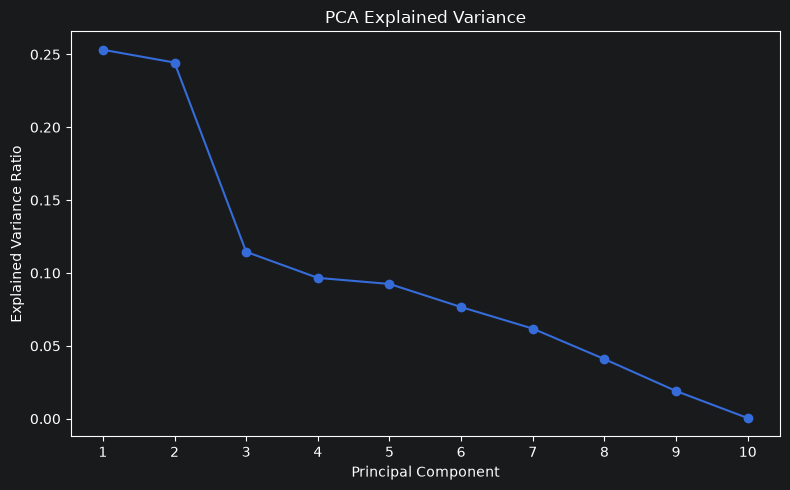

In [8]:
# plot explained variance

plt.figure(figsize=(8, 5))
plt.plot(variance_table["component"],variance_table["explained_variance"],marker="o")

plt.title("PCA Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(variance_table["component"])

plt.tight_layout()
plt.show()

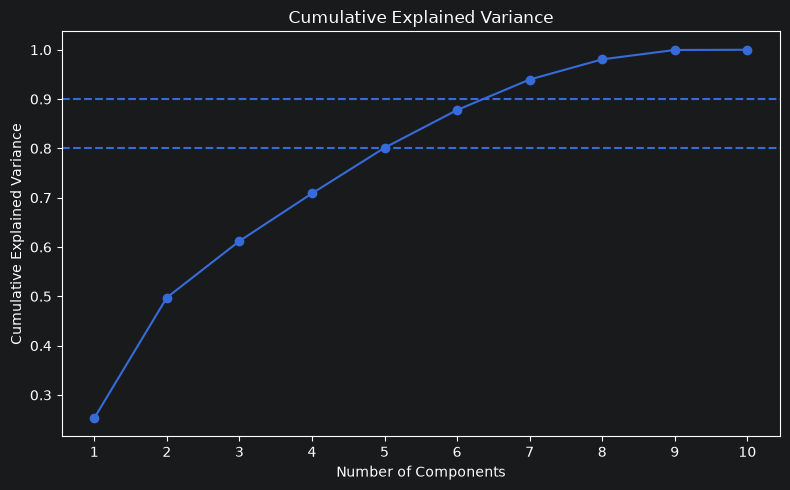

In [9]:
# plot cumulative variance

plt.figure(figsize=(8, 5))
plt.plot(variance_table["component"],variance_table["cumulative_variance"],marker="o")
plt.axhline(y=0.8,linestyle="--")
plt.axhline(y=0.9,linestyle="--")

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(variance_table["component"])

plt.tight_layout()
plt.show()

### pca findings

the first principal component explains about 25 percent of the variance

the second principal component explains about 24 percent

together the first two components explain about 50 percent of the total variance

five components are needed to keep about 80 percent of the information

seven components keep about 94 percent of the information

this shows that the dataset has some redundancy but the information is still spread across several dimensions

a two dimensional projection is useful for visualization but it loses about half of the total variance

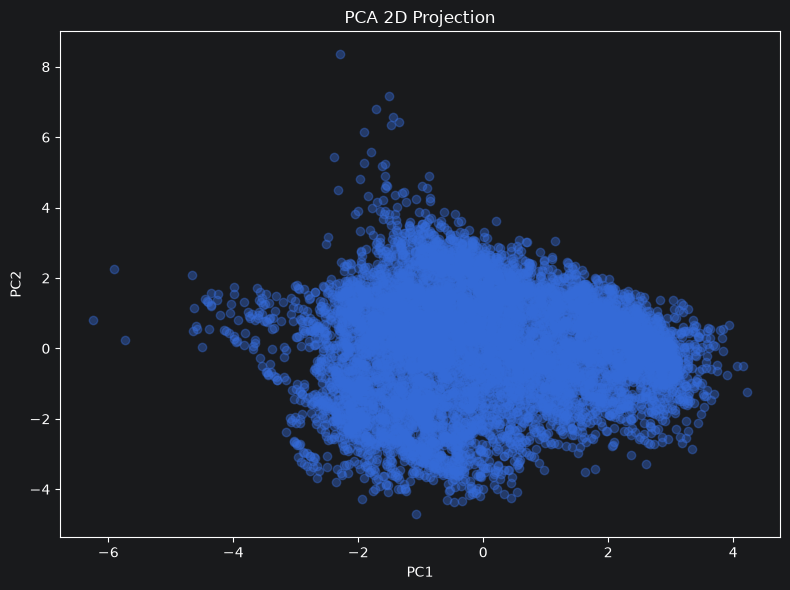

In [10]:
# create 2d pca projection

pca_2d = PCA(n_components=2)
pca_2d_data = pca_2d.fit_transform(scaled_data)
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_data[:, 0],pca_2d_data[:, 1],alpha=0.4)

plt.title("PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

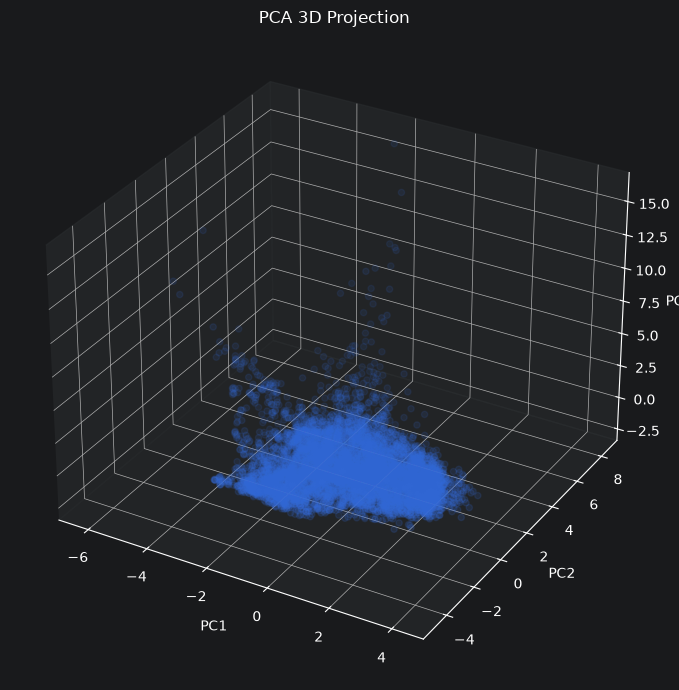

In [11]:
# create 3d pca projection

pca_3d = PCA(n_components=3)
pca_3d_data = pca_3d.fit_transform(scaled_data)
fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(111,projection="3d")
ax.scatter(pca_3d_data[:, 0],pca_3d_data[:, 1],pca_3d_data[:, 2],alpha=0.4)

ax.set_title("PCA 3D Projection")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.tight_layout()
plt.show()

In [12]:
# show pca feature contributions
pca_loadings = pd.DataFrame(pca.components_[:3],columns=numerical_features,index=["pc1", "pc2", "pc3"])
pca_loadings.round(3)

,rented_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall
pc1,0.494,0.291,0.498,-0.191,0.190,0.204,0.345,0.380,-0.067,-0.203
pc2,0.021,-0.158,0.344,0.546,-0.315,-0.346,0.514,-0.186,0.197,-0.024
pc3,0.015,0.470,-0.074,0.117,0.444,-0.365,-0.036,0.098,0.486,0.427


### pca component interpretation

pc1 is mainly influenced by temperature rented bike count solar radiation and dew point temperature

this component seems to represent warmer and more active conditions with higher bike demand

pc2 is mainly influenced by humidity and dew point temperature while visibility and wind speed contribute in the opposite direction

this component seems to describe differences in moisture and atmospheric conditions

pc3 is mainly influenced by rainfall hour wind speed and snowfall

this component seems to represent weather events and time related variation

the strong contribution of temperature and dew point temperature also supports the correlation analysis which showed that these features contain similar information

### pca projection findings

the 2d projection does not show clearly separated clusters

most observations form one large continuous group with some extreme points around it

the 3d projection shows more structure and makes some unusual observations easier to see

however the first three components still do not represent all of the original information

this means that the pca projection is useful for visualization but should not be treated as a complete representation of the dataset

## 4 clustering analysis

in this section i will apply several clustering methods to the scaled numerical data

the goal is to check whether the observations form meaningful groups and to compare how different methods describe the structure of the dataset

In [13]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

### k means

k means divides the observations into groups around cluster centers

the algorithm tries to minimize the distance between observations and the center of their cluster

it works best when clusters are relatively compact and separated

In [14]:
# test different numbers of clusters
k_results = []

for k in range(2, 7):

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data,labels)
    k_results.append({"k": k,"silhouette": score})

k_results_df = pd.DataFrame(k_results)
k_results_df.round(3)

,k,silhouette
0,2,0.197
1,3,0.229
2,4,0.236
3,5,0.213
4,6,0.235


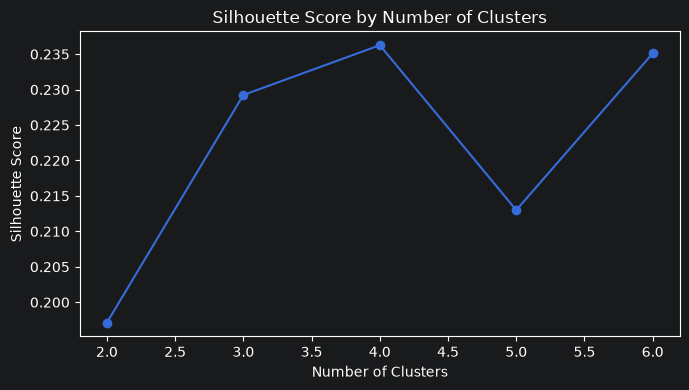

In [15]:
# plot silhouette score by k

plt.figure(figsize=(7, 4))
plt.plot(k_results_df["k"],k_results_df["silhouette"],marker="o")

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

### k means selection

the highest silhouette score was obtained with 4 clusters

the silhouette score is about 0.236 which is still relatively low

this suggests that the dataset does not contain very clearly separated clusters

the result is consistent with the pca projection where most observations formed one continuous structure

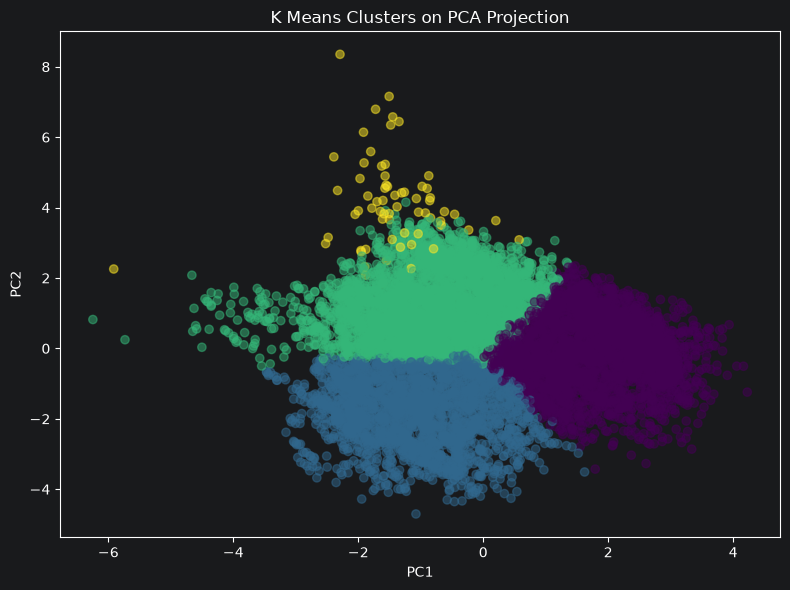

In [16]:
# create final k means model
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)
bike_data["kmeans_cluster"] = kmeans_labels

# check cluster sizes
bike_data["kmeans_cluster"].value_counts().sort_index()

# show k means clusters on pca
plt.figure(figsize=(8, 6))

plt.scatter(pca_2d_data[:, 0],pca_2d_data[:, 1],c=kmeans_labels,alpha=0.5)
plt.title("K Means Clusters on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [17]:
# compare cluster variance with global variance

global_variance = scaled_data.var(axis=0).mean()

cluster_variances = []

for cluster in range(4):

    cluster_data = scaled_data[kmeans_labels == cluster]
    cluster_variance = (cluster_data.var(axis=0).mean())
    cluster_variances.append(cluster_variance)

print("global variance:",round(global_variance, 3))
for cluster, variance in enumerate(cluster_variances):
    print(f"cluster {cluster} variance:",round(variance, 3))

global variance: 1.0
cluster 0 variance: 0.54
cluster 1 variance: 0.51
cluster 2 variance: 0.663
cluster 3 variance: 3.547


### k means findings

the k means result shows some visible separation between the four clusters

clusters 0 1 and 2 have lower average variance than the full dataset

this means that these clusters are more compact than the complete dataset

cluster 3 has a much higher variance of about 3.55

this suggests that cluster 3 contains more scattered or unusual observations

the clusters still overlap in the pca projection so the separation is not very strong

this agrees with the relatively low silhouette score

In [18]:
# check cluster sizes
bike_data["kmeans_cluster"].value_counts().sort_index()

# compare average values between clusters
cluster_summary = (bike_data.groupby("kmeans_cluster")[numerical_features].mean().round(2))

cluster_summary

,rented_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall
kmeans_cluster,,,,,,,,,,
0,1360.25,15.57,22.86,50.10,2.06,1647.11,11.25,1.24,0.00,0.00
1,321.53,12.14,-0.97,41.46,2.09,1748.16,-12.90,0.38,0.00,0.11
2,402.11,7.54,13.33,75.66,1.19,1064.49,8.86,0.12,0.17,0.12
3,71.06,11.73,17.57,96.09,1.54,580.95,16.89,0.06,10.68,0.11


### real world interpretation

cluster 0 represents warmer conditions with high bike demand

this cluster also has higher solar radiation and relatively good visibility

cluster 1 represents colder conditions with lower bike demand

temperature and dew point temperature are much lower in this cluster

cluster 2 represents more humid conditions with medium bike demand and low solar radiation

cluster 3 represents very rainy and humid conditions with very low bike demand

visibility is also much lower in cluster 3 which supports the idea that this cluster represents bad weather conditions

the clusters therefore have some real world meaning even though the separation between them is not very strong

### dbscan

dbscan groups observations based on local density

points that are close to enough nearby observations become part of a cluster

points that are isolated can be marked as noise

unlike k means dbscan does not require choosing the number of clusters in advance

In [19]:
# apply dbscan

dbscan = DBSCAN(eps=0.9,min_samples=10)
dbscan_labels = dbscan.fit_predict(scaled_data)
bike_data["dbscan_cluster"] = dbscan_labels

# check dbscan results
dbscan_counts = (bike_data["dbscan_cluster"].value_counts().sort_index())
dbscan_counts

dbscan_cluster
-1    1378
 0    7272
 1      10
 2      11
 3      16
 4      30
 5       8
 6      10
 7       9
 8      16
Name: count, dtype: int64

number of clusters: 9
noise points: 1378


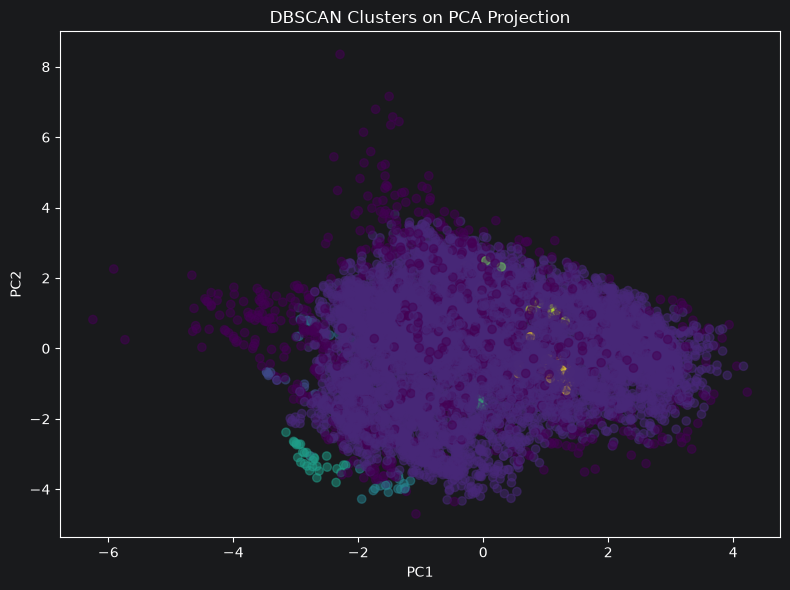

In [20]:
# count clusters and noise
number_of_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
number_of_noise = np.sum(dbscan_labels == -1)

print("number of clusters:", number_of_clusters)
print("noise points:", number_of_noise)

# show dbscan clusters on pca
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_data[:, 0],pca_2d_data[:, 1],c=dbscan_labels,alpha=0.5)

plt.title("DBSCAN Clusters on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

### dbscan cluster structure

most observations were assigned to one large cluster

7272 observations belong to cluster 0

1378 observations were marked as noise

the remaining clusters are very small and contain only a few observations each

this suggests that the dataset does not contain many large well separated density based clusters

instead dbscan finds one main dense region together with small local groups and isolated observations

In [ ]:
# test different dbscan eps values
dbscan_results = []
for eps in [0.6, 0.8, 0.9, 1.0, 1.2]:

    model = DBSCAN(eps=eps,min_samples=10)
    labels = model.fit_predict(scaled_data)
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = np.sum(labels == -1)
    dbscan_results.append({"eps": eps,"clusters": clusters,"noise": noise})

pd.DataFrame(dbscan_results)

### dbscan parameter sensitivity

the dbscan result changes strongly when eps is changed

smaller eps values create more clusters and classify many observations as noise

larger eps values connect more observations together and reduce the number of noise points

for example eps 0.6 produced 18 clusters and 5563 noise points while eps 1.2 produced only 6 clusters and 344 noise points

this shows that dbscan is very sensitive to the selected distance threshold

eps 0.9 was kept as a middle value for the main analysis

### hierarchical clustering

hierarchical clustering gradually combines similar observations into larger groups

the method creates a hierarchy of clusters instead of directly searching for cluster centers

in this analysis ward linkage will be used which tries to keep the variance inside each cluster as small as possible

In [ ]:
# apply hierarchical clustering
hierarchical_model = AgglomerativeClustering(n_clusters=4,linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(scaled_data)
bike_data["hierarchical_cluster"] = hierarchical_labels

# check cluster sizes
bike_data["hierarchical_cluster"].value_counts().sort_index()

In [ ]:
# calculate silhouette score
hierarchical_silhouette = silhouette_score(scaled_data,hierarchical_labels)
print("silhouette score:",round(hierarchical_silhouette, 3))

In [ ]:
# show hierarchical clusters on pca
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_data[:, 0],pca_2d_data[:, 1],c=hierarchical_labels,alpha=0.5)

plt.title("Hierarchical Clusters on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [ ]:
# compare average values between clusters
hierarchical_summary = (bike_data.groupby("hierarchical_cluster")[numerical_features].mean().round(2))
hierarchical_summary

### hierarchical clustering findings

the hierarchical clustering result produced four clusters with different sizes

the silhouette score is 0.21 which is slightly lower than the k means result

this suggests that the cluster separation is relatively weak

cluster 1 represents warmer conditions with high bike demand and high solar radiation

cluster 2 represents colder and drier conditions with lower bike demand

cluster 0 represents more humid conditions with medium demand

cluster 3 is much smaller than the other clusters and contains observations with much higher snowfall and low bike demand

the hierarchical result is similar to k means in some areas but the exact cluster boundaries are different

### feature space clustering

in this section the features will be clustered instead of the observations

this can help identify features that behave similarly and may contain related or redundant information

In [ ]:
# transpose the scaled data
feature_space = scaled_data.T

# cluster the features

feature_cluster_model = AgglomerativeClustering(n_clusters=3,linkage="ward")
feature_labels = feature_cluster_model.fit_predict(feature_space)

# show feature clusters
feature_clusters = pd.DataFrame({"feature": numerical_features,"cluster": feature_labels})
feature_clusters.sort_values("cluster")

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
# create feature dendrogram
feature_linkage = linkage(feature_space,method="ward")

plt.figure(figsize=(10, 5))
dendrogram(feature_linkage,labels=numerical_features,leaf_rotation=45)

plt.title("Feature Clustering Dendrogram")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### feature clustering findings

the feature clustering revealed several meaningful groups

temperature and dew point temperature were placed in the same cluster

this agrees with the strong correlation between these two features and suggests that they contain partly redundant information

humidity rainfall and snowfall were grouped together

these features are all related to moisture and precipitation conditions

rented bike count hour visibility wind speed and solar radiation were placed in another larger cluster

this group contains features related to time demand and general outdoor conditions

the dendrogram also shows that temperature and dew point temperature are very close to each other

feature clustering therefore revealed relationships that were also visible in the correlation matrix and pca analysis

### feature space discussion

the feature clustering helped identify possible redundancy especially between temperature and dew point temperature

some features joined only at larger distances in the dendrogram which suggests that they behave differently from the closest feature groups

clustering the features gives a different view of the data because it focuses on relationships between variables instead of relationships between observations

this type of analysis can be useful when selecting features or when trying to reduce redundant information

## 5 multi dimensional anomaly detection

### 5.1 z score method

the z score measures how far a value is from the mean in units of standard deviation

values with a large absolute z score may be considered unusual

in this analysis an observation will be marked as anomalous if at least one numerical feature has an absolute z score larger than 3

In [ ]:
from scipy.stats import zscore
# calculate z scores
z_scores = np.abs(zscore(pca_features))
z_score_df = pd.DataFrame(z_scores,columns=numerical_features)

# mark z score anomalies
z_threshold = 3
z_anomaly_mask = (z_score_df > z_threshold).any(axis=1)
bike_data["z_anomaly"] = z_anomaly_mask

# count z score anomalies
print("z score anomalies:",bike_data["z_anomaly"].sum())
print("percent of dataset:",round(bike_data["z_anomaly"].mean() * 100,2))

# count extreme values by feature
z_feature_counts = (z_score_df > z_threshold).sum().sort_values(ascending=False)
z_feature_counts

In [ ]:
# show z score anomalies on pca
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_data[~z_anomaly_mask, 0],pca_2d_data[~z_anomaly_mask, 1],alpha=0.3,label="normal")
plt.scatter(pca_2d_data[z_anomaly_mask, 0],pca_2d_data[z_anomaly_mask, 1],alpha=0.7,label="anomaly")

plt.title("Z Score Anomalies on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

### z score discussion

the z score method is simple and easy to interpret

however it works best when the features are close to normally distributed

this is a limitation in this dataset because rainfall snowfall and solar radiation are strongly skewed

in high dimensional data an observation may appear unusual in one feature even if it is not truly abnormal overall

the feature wise approach can therefore produce more false alarms when many features are tested

### z score findings

the z score method detected 475 anomalies which is about 5.42 percent of the dataset

most anomalies were caused by snowfall rainfall solar radiation rented bike count and wind speed

snowfall produced the largest number of extreme z scores

this is consistent with the earlier distribution analysis because snowfall and rainfall were strongly skewed and had heavy tails

the pca visualization shows that many detected anomalies are located around the outer regions of the data

however some anomalous points also appear inside the main data cloud

this shows that a feature can be extreme even when the observation does not look isolated in a two dimensional pca projection

### 5.2 isolation forest

isolation forest detects anomalies by randomly splitting the data

unusual observations are usually easier to isolate and therefore require fewer random splits

normal observations usually need more splits because they are located inside dense regions of the data

the contamination parameter controls the expected proportion of anomalies in the dataset

In [ ]:
from sklearn.ensemble import IsolationForest
# apply isolation forest
isolation_forest = IsolationForest(contamination=0.05,random_state=42)
isolation_labels = isolation_forest.fit_predict(scaled_data)

# mark isolation forest anomalies
isolation_anomaly_mask = (isolation_labels == -1)
bike_data["isolation_anomaly"] = (isolation_anomaly_mask)

# count isolation forest anomalies
print("isolation forest anomalies:",isolation_anomaly_mask.sum())
print("percent of dataset:",round(isolation_anomaly_mask.mean() * 100,2))

# calculate anomaly scores
isolation_scores = (-isolation_forest.score_samples(scaled_data))
bike_data["isolation_score"] = isolation_scores

In [ ]:
# show isolation forest anomalies on pca

plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_data[~isolation_anomaly_mask, 0],pca_2d_data[~isolation_anomaly_mask, 1],alpha=0.3,label="normal")
plt.scatter(pca_2d_data[isolation_anomaly_mask, 0],pca_2d_data[isolation_anomaly_mask, 1],alpha=0.7,label="anomaly")

plt.title("Isolation Forest Anomalies on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# show strongest anomalies
bike_data[["rented_count","hour","temperature","humidity","wind_speed","visibility","dew_point_temp","solar_radiation","rainfall","snowfall","isolation_score"]].sort_values("isolation_score",ascending=False).head(10)

### isolation forest discussion

isolation forest does not require the features to follow a normal distribution

this makes it more suitable than z score for skewed features such as rainfall and snowfall

the method can also detect unusual combinations of several features instead of looking at each feature separately

however the result depends on the contamination parameter

a higher contamination value will force the model to classify more observations as anomalies

the anomaly score represents how easily an observation can be isolated from the rest of the data

### isolation forest findings

isolation forest detected 438 anomalies which is exactly 5 percent of the dataset

this result is expected because the contamination parameter was set to 0.05

many detected anomalies appear around the outer regions of the pca projection

however some anomalous observations are also located inside the main cloud

this shows that isolation forest uses the full multidimensional structure and not only the two dimensional pca projection

the strongest anomalies often contain unusual combinations of rainfall snowfall humidity visibility and wind speed

these observations may be difficult to identify using a simple feature by feature rule

### anomaly score interpretation

a higher isolation score means that the observation is easier to isolate from the rest of the data

observations with high scores are therefore more unusual

the strongest anomalies in this dataset often combine several unusual weather conditions at the same time

### 5.3 local outlier factor

lof detects anomalies by comparing the local density of each observation with the density of its neighbors

an observation can be considered anomalous if it is located in a much less dense area than nearby observations

this makes lof useful for finding local anomalies that may not look unusual when compared with the full dataset

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# apply lof
lof = LocalOutlierFactor(n_neighbors=20,contamination=0.05)
lof_labels = lof.fit_predict(scaled_data)

# mark lof anomalies
lof_anomaly_mask = (lof_labels == -1)
bike_data["lof_anomaly"] = (lof_anomaly_mask)

# count lof anomalies
print("lof anomalies:",lof_anomaly_mask.sum())
print("percent of dataset:",round(lof_anomaly_mask.mean() * 100,2))


In [ ]:
# calculate lof scores
lof_scores = (-lof.negative_outlier_factor_)
bike_data["lof_score"] = lof_scores

# show lof anomalies on pca
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_data[~lof_anomaly_mask, 0],pca_2d_data[~lof_anomaly_mask, 1],alpha=0.3,label="normal")
plt.scatter(pca_2d_data[lof_anomaly_mask, 0],pca_2d_data[lof_anomaly_mask, 1],alpha=0.7,label="anomaly")

plt.title("LOF Anomalies on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# show strongest lof anomalies
bike_data[["rented_count","hour","temperature","humidity","wind_speed","visibility","dew_point_temp","solar_radiation","rainfall","snowfall","lof_score"]].sort_values("lof_score",ascending=False).head(10)

In [ ]:
# compare anomalies for different neighborhood sizes
baseline_anomalies = lof_anomaly_mask
lof_sensitivity = []
for neighbors in [10, 20, 30, 50]:

    model = LocalOutlierFactor(n_neighbors=neighbors,contamination=0.05)
    labels = model.fit_predict(scaled_data)
    anomalies = (labels == -1)
    overlap = np.sum(anomalies & baseline_anomalies)
    lof_sensitivity.append({"neighbors": neighbors,"same_anomalies_as_k20": overlap,"agreement_percent": overlap / baseline_anomalies.sum() * 100})

pd.DataFrame(lof_sensitivity).round(2)

### lof discussion

lof focuses on local density instead of global distance

this means that an observation can be unusual compared with its local neighborhood even if it is not extreme in the full dataset

the choice of the number of neighbors affects what the model considers local

small neighborhood values focus on very local structure while larger values compare observations with a wider region

this makes lof sensitive to the selected neighborhood size

### lof findings

lof detected 438 anomalies which is 5 percent of the dataset

many anomalies appear around the outer regions of the pca projection

however lof also identifies unusual observations inside the main data cloud

this happens because lof compares each observation with its local neighborhood

the strongest anomalies often contain unusual weather conditions such as high snowfall rainfall humidity or wind speed

this shows that lof can detect local anomalies that may not look globally extreme

### lof parameter sensitivity

the total number of anomalies stays the same because contamination was fixed at 0.05

however the actual observations classified as anomalies change when the number of neighbors changes

using 10 neighbors produced about 68 percent agreement with the result using 20 neighbors

using 30 neighbors produced about 81 percent agreement

using 50 neighbors produced about 63 percent agreement

this shows that lof is sensitive to the neighborhood size even when the total number of detected anomalies stays constant

# 6 comparison of anomaly detection methods

in this section i will compare the z score isolation forest and lof results

the goal is to check where the methods agree and where they identify different observations as anomalous

In [ ]:
# compare anomaly detection methods

z_set = set(bike_data.index[bike_data["z_anomaly"]])
isolation_set = set(bike_data.index[bike_data["isolation_anomaly"]])
lof_set = set(bike_data.index[bike_data["lof_anomaly"]])

all_three = (z_set& isolation_set& lof_set)

z_isolation = (z_set& isolation_set)
z_lof = (z_set& lof_set)
isolation_lof = (isolation_set& lof_set)

print("z score anomalies:", len(z_set))
print("isolation forest anomalies:", len(isolation_set))
print("lof anomalies:", len(lof_set))

print("z score and isolation forest:", len(z_isolation))
print("z score and lof:", len(z_lof))
print("isolation forest and lof:", len(isolation_lof))
print("all three methods:", len(all_three))

In [ ]:
# count method specific anomalies
z_only = (z_set- isolation_set- lof_set)
isolation_only = (isolation_set- z_set- lof_set)
lof_only = (lof_set- z_set- isolation_set)

print("z score only:", len(z_only))
print("isolation forest only:", len(isolation_only))
print("lof only:", len(lof_only))

In [ ]:
# create comparison table
comparison_table = pd.DataFrame({"method": ["z score","isolation forest","lof"],"anomalies": [len(z_set),len(isolation_set),len(lof_set)],"unique_anomalies": [len(z_only),len(isolation_only),len(lof_only)]})
comparison_table

### comparison findings

the three anomaly detection methods do not fully agree with each other

z score detected 475 anomalies while isolation forest and lof each detected 438

only 52 observations were detected as anomalies by all three methods

z score and isolation forest had the highest agreement with 264 shared anomalies

lof had much lower agreement with the other methods

lof also detected 330 anomalies that were unique to this method

this shows that each method uses a different definition of what is unusual

z score focuses on extreme feature values

isolation forest looks for observations that are easy to isolate in the full feature space

lof focuses on observations with low local density compared with their neighbors

### method comparison

z score is easy to understand and very fast but it is sensitive to skewed distributions and works best when the data is close to gaussian

isolation forest handles non linear and multidimensional patterns better and does not require gaussian features

lof is useful for detecting local anomalies but it is sensitive to the choice of neighborhood size

all three methods are affected by feature scaling because features with larger ranges can dominate distance or statistical calculations

scaling is especially important for lof because it depends directly on distances between observations

higher dimensionality can make distance based methods less reliable because observations become more similar in terms of distance

isolation forest usually scales better to larger datasets than lof because lof must compare local neighborhoods

z score is the easiest method to interpret

isolation forest is less direct but still gives an anomaly score

lof is useful for local structure but its results can be harder to explain to a non technical audience

### false positives and false negatives

a false positive would mean that a normal bike sharing observation is incorrectly marked as unusual

this could happen during valid but rare weather conditions such as heavy rain or snow

a false negative would mean that a truly unusual observation is missed by the anomaly detection method

this could cause important unusual demand or weather patterns to be ignored

too many false positives would make the system less useful because normal observations would require unnecessary investigation

too many false negatives could cause real unusual events to remain undetectedע

## 7 critical analysis and reflection

anomaly detection is difficult because there is usually no clear label that tells us which observations are truly abnormal

different methods use different definitions of unusual behavior so they can produce different results

this was visible in this project because the three anomaly detection methods agreed on only a small number of observations

### curse of dimensionality

as the number of features increases the data becomes more spread out in the feature space

distances between observations can become less informative because many points start to appear similarly far from each other

this can reduce the reliability of distance based methods such as lof

it can also make it harder to understand whether an observation is truly unusual or only different in one dimension

### noise and genuine anomalies

an unusual observation is not always an error

for example heavy rainfall or snowfall may be rare but still represent a real weather event

such observations may be detected as anomalies even though the measurements are valid

noise would instead represent incorrect or unreliable measurements

without ground truth it can be difficult to know whether an unusual observation is noise or a real rare event

### gaussian assumption

assuming that all features follow a gaussian distribution can be risky

rainfall snowfall and solar radiation are clearly not normally distributed in this dataset

a z score method may therefore classify valid rare weather events as anomalies

it may also miss unusual combinations of features when no single feature has an extreme value

### limitations of pca visualization

pca is useful for visualizing high dimensional data but it does not preserve all of the original information

the first two principal components explained only about half of the total variance

this means that two observations may look close in the pca plot while still being very different in the original feature space

anomalies or clusters may therefore look weaker or stronger in the pca visualization than they really are

### ethical considerations

false alarms can make an anomaly detection system less useful because users may stop trusting the alerts

in surveillance systems anomaly detection may help identify unusual activity but it can also create privacy and fairness concerns

in medical applications a false positive could cause unnecessary stress or testing while a false negative could miss an important medical condition

in cybersecurity a false negative may allow a real attack to remain undetected while too many false positives can overwhelm security teams

anomaly detection systems should therefore be used carefully because labeling people or behavior as abnormal can have serious consequences

privacy bias fairness and the cost of incorrect decisions should always be considered

## 8 final visualization dashboard

this section gives a visual summary of the main results from the project

it includes pca clustering anomaly detection pairplots and correlation heatmaps

In [ ]:
# show k means clusters on pca
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_data[:, 0],pca_2d_data[:, 1],c=kmeans_labels,alpha=0.5)

plt.title("K Means Clusters on PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [ ]:
# show isolation forest anomalies

plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_data[~isolation_anomaly_mask, 0],pca_2d_data[~isolation_anomaly_mask, 1],alpha=0.3,label="normal")
plt.scatter(pca_2d_data[isolation_anomaly_mask, 0],pca_2d_data[isolation_anomaly_mask, 1],alpha=0.7,label="anomaly")

plt.title("Isolation Forest Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# choose columns for pairplot
pairplot_columns = ["rented_count","temperature","humidity","wind_speed","solar_radiation","kmeans_cluster"]
pairplot_sample = bike_data[pairplot_columns].sample(n=1500,random_state=42)

# make pairplot
sns.pairplot(pairplot_sample,vars=["rented_count","temperature","humidity","wind_speed","solar_radiation"],hue="kmeans_cluster",corner=True,plot_kws={"alpha": 0.4,"s": 20})
plt.show()

In [ ]:
# show correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# prepare anomaly data

interactive_data = pd.DataFrame({
        "pc1": pca_2d_data[:, 0],
        "pc2": pca_2d_data[:, 1],
        "isolation_anomaly": bike_data["isolation_anomaly"],
        "rented_count": bike_data["rented_count"],
        "temperature": bike_data["temperature"],
        "humidity": bike_data["humidity"],
        "rainfall": bike_data["rainfall"],
        "snowfall": bike_data["snowfall"]})

In [ ]:
# show anomaly exploration plot
plt.figure(figsize=(9, 6))

plt.scatter(
    interactive_data.loc[~interactive_data["isolation_anomaly"],"pc1"],
    interactive_data.loc[~interactive_data["isolation_anomaly"],"pc2"],alpha=0.3,label="normal")

plt.scatter(
    interactive_data.loc[interactive_data["isolation_anomaly"],"pc1"],
    interactive_data.loc[interactive_data["isolation_anomaly"],"pc2"],alpha=0.7,label="anomaly")

plt.title("Isolation Forest Anomaly Exploration")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# show anomaly exploration plot
plt.figure(figsize=(9, 6))
plt.scatter(
    interactive_data.loc[~interactive_data["isolation_anomaly"],"pc1"],
    interactive_data.loc[~interactive_data["isolation_anomaly"],"pc2"],alpha=0.3,label="normal")

plt.scatter(
    interactive_data.loc[interactive_data["isolation_anomaly"],"pc1"],
    interactive_data.loc[interactive_data["isolation_anomaly"],"pc2"],alpha=0.7,label="anomaly")

plt.title("Isolation Forest Anomaly Exploration")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

### anomaly exploration

the anomaly plot makes it easier to compare normal and unusual observations in the pca space

the anomalies are mostly located around the outer areas of the data but some also appear inside the main group

In [ ]:
# final scientific result
x = ["before the course", "after the homework"]
y = [100, 12]

plt.figure(figsize=(8, 5))
plt.bar(x,y,edgecolor="black")

plt.ylabel("remaining brain power")
plt.title("my will to live")
plt.tight_layout()
plt.show()